# Reinforcement Learning for State Separation

## Setup

In [1]:
%pip install matplotlib

import json
import math 
import numpy as np
import os
import pandas as pd
from pprint import pprint
from matplotlib import pyplot as plt
from statistics import mean, median, stdev
from typing import List 

You should consider upgrading via the '/Users/christophstein/Documents/jku/qcs-rl/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
plt.rcParams["figure.dpi"] = 120

In [3]:
LOG_DIR = "logs"

In [4]:
def printb(text: str) -> None:
    print("\033[1m" + text + "\033[0m")

## Data Loading Functions

In [5]:
def load_json(path: str):
    with open(path, "r") as config_file:
        return json.load(config_file)

In [6]:
def load_monitor_data(path: str, n_eval_episodes: int, episode_cutoff: int, eval_frequency: int) -> pd.DataFrame:
    monitor_df_raw = pd.read_csv(path, skiprows=1)

    assert len(monitor_df_raw) % n_eval_episodes == 0

    per_eval_data = []
    for i in range(int(len(monitor_df_raw) / n_eval_episodes)):

        start_step = i * n_eval_episodes
        end_step = start_step + n_eval_episodes

        current_eval_df = monitor_df_raw[start_step: end_step + 1]

        r_mean = current_eval_df["r"].mean()
        r_stdev = current_eval_df["r"].std()

        # only compute length scores for successful rounds
        current_eval_succ_df = current_eval_df[current_eval_df["l"] < episode_cutoff]
        l_mean = current_eval_succ_df["l"].mean()
        l_stdev = current_eval_succ_df["l"].std()

        succ_pct = len(current_eval_succ_df) / len(current_eval_df)

        train_step = (i + 1) * eval_frequency
        train_step = f"{round(train_step / 10**6, 2)} Mio."

        per_eval_data.append({
            "steps": train_step,
            "r_mean": r_mean,
            "r_stdev": r_stdev,
            "r_lower_bound": r_mean - r_stdev,
            "r_upper_bound": r_mean + r_stdev,
            "l_mean": l_mean,
            "l_stdev": l_stdev,
            "l_lower_bound": l_mean - l_stdev,
            "l_upper_bound": l_mean + l_stdev,
            "succ_pct": succ_pct,
        })


    return pd.DataFrame(per_eval_data)


In [7]:
def merge_seed_dfs(seed_dfs: List[pd.DataFrame]) -> pd.DataFrame:
    # assert same lengths
    assert len(set([len(df) for df in seed_dfs])) == 1, "All seed runs need to have the same amount of steps!"

    merged_data = []

    for i in range(len(seed_dfs[0])):

        steps = []
        r_seed_means = []
        l_seed_means = []
        succ_pct_seed_means = []

        for seed_df in seed_dfs:
            row = seed_df.iloc[[i]]
            steps.append(row["steps"].values[0]) 
            r_seed_means.append(row["r_mean"].values[0]) 
            l_seed_means.append(row["l_mean"].values[0]) 
            succ_pct_seed_means.append(row["succ_pct"].values[0]) 

        assert len(set(steps)) == 1, "Steps mismatch between seed runs!"

        r_mean = mean(r_seed_means)
        r_stdev = stdev(r_seed_means)
        l_mean = mean(l_seed_means)
        l_stdev = stdev(l_seed_means)
        succ_pct_mean = mean(succ_pct_seed_means)
        succ_pct_stdev= stdev(succ_pct_seed_means)

        merged_data.append({
            "steps": steps[0],
            "r_mean": r_mean,
            "r_stdev": r_stdev,
            "r_lower_bound": r_mean - r_stdev,
            "r_upper_bound": r_mean + r_stdev,
            "l_mean": l_mean,
            "l_stdev": l_stdev,
            "l_lower_bound": l_mean - l_stdev,
            "l_upper_bound": l_mean + l_stdev,
            "succ_pct_mean": succ_pct_mean,
            "succ_pct_stdev": succ_pct_stdev,
            "succ_pct_lower_bound": succ_pct_mean - succ_pct_stdev,
            "succ_pct_upper_bound": succ_pct_mean + succ_pct_stdev,
        })

    return pd.DataFrame(merged_data)

## Data Analysis Functions

In [8]:
def plot_rewards(dfs: List[pd.DataFrame], labels: List[str], plot_stdev: bool = True):
    ax = plt.subplot()

    for df, label in zip(dfs, labels):
        ax.plot(df["steps"], df["r_mean"], label=label)

        if plot_stdev:
            ax.fill_between(
                df["steps"], df["r_lower_bound"], df["r_upper_bound"], alpha=0.3
            )

    ax.set_xlabel("steps")
    ax.set_ylabel("reward")

    if len(dfs) > 1:
        plt.legend()

    plt.grid()
    plt.xticks(fontsize=8, rotation=45)
    plt.setp(ax.get_xticklabels()[::5], visible=True)
    plt.show()

In [9]:
def plot_circuit_lengths(dfs: List[pd.DataFrame], labels: List[str], plot_stdev: bool = True):
    ax = plt.subplot()

    for df, label in zip(dfs, labels):
        ax.plot(df["steps"], df["l_mean"], label=label)

        if plot_stdev:
            ax.fill_between(
                df["steps"], df["l_lower_bound"], df["l_upper_bound"], alpha=0.3
            )

    ax.set_xlabel("steps")
    ax.set_ylabel("circuit length of successfull runs")

    if len(dfs) > 1:
        plt.legend()

    plt.grid()
    plt.xticks(fontsize=8, rotation=45)
    plt.show()

In [10]:
def plot_succ_pct_per_seed(dfs: List[pd.DataFrame], labels: List[str]):
    ax = plt.subplot()

    for df, label in zip(dfs, labels):
        ax.plot(df["steps"], df["succ_pct"], label=label)

    ax.set_xlabel("steps")
    ax.set_ylabel("success percentage")

    if len(dfs) > 1:
        plt.legend()

    plt.grid()
    plt.xticks(fontsize=8, rotation=45)
    plt.show()

In [11]:
def plot_succ_pct_per_experiment(dfs: List[pd.DataFrame], labels: List[str], plot_stdev: bool = True):
    ax = plt.subplot()

    for df, label in zip(dfs, labels):
        ax.plot(df["steps"], df["succ_pct_mean"], label=label)

        if plot_stdev:
            ax.fill_between(
                df["steps"], df["succ_pct_lower_bound"], df["succ_pct_upper_bound"], alpha=0.3
            )

    ax.set_xlabel("steps")
    ax.set_ylabel("success percentage")

    if len(dfs) > 1:
        plt.legend()

    plt.grid()
    plt.xticks(fontsize=8, rotation=45)
    plt.show()

## Main


2q_10g_base:
{'common_params': {'max_steps': 10, 'qubit_num': 2, 'seed': 3, 'tag': 'base'},
 'start_time': '2025-09-17 18:29:05.713988',
 'state_generator_params': {'gate_count': 10,
                            'max_generation_tries': 1000000,
                            'targeted_pool_size': 10000,
                            'test_pool_size': 3000,
                            'train_pool_size': 7000,
                            'train_test_split': 0.3},
 'test_env_params': {'eval_freq': 50000, 'n_eval_episodes': 1000},
 'train_params': {'log_interval': 1000, 'total_timesteps': 5000000}}

Aggregated results:


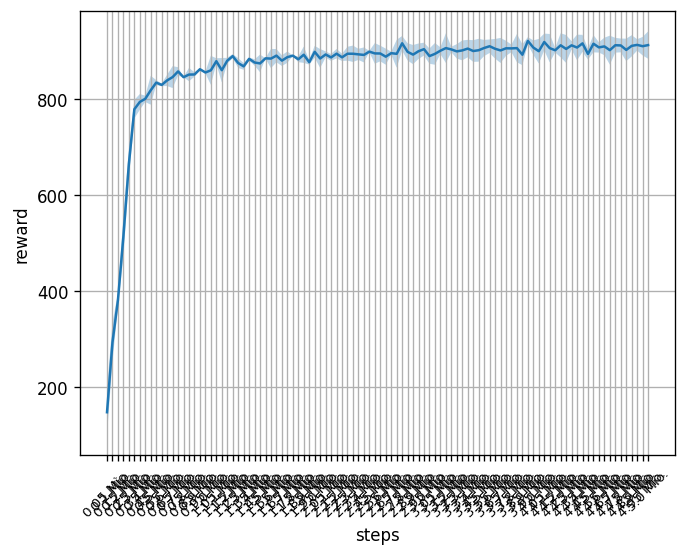

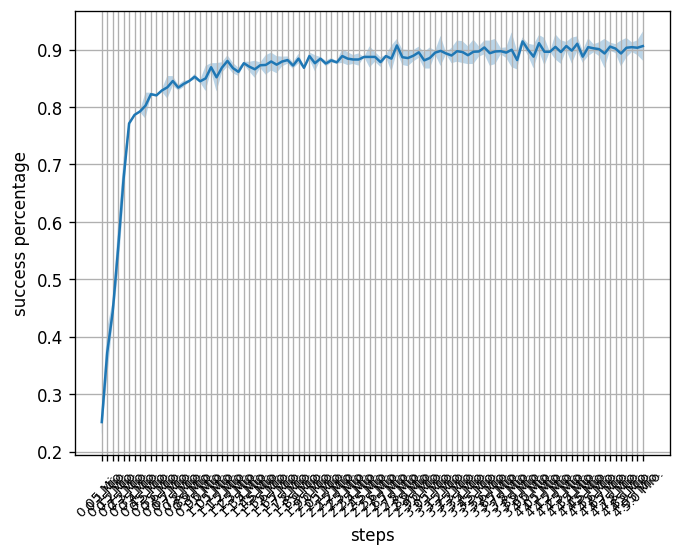

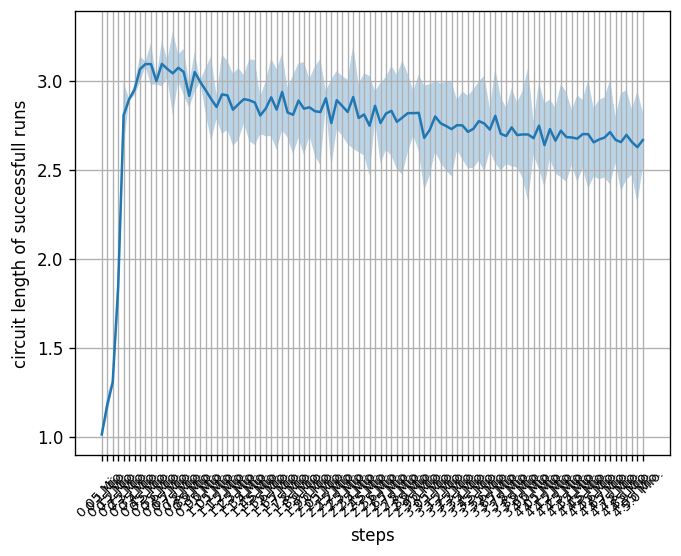


Per seed results:


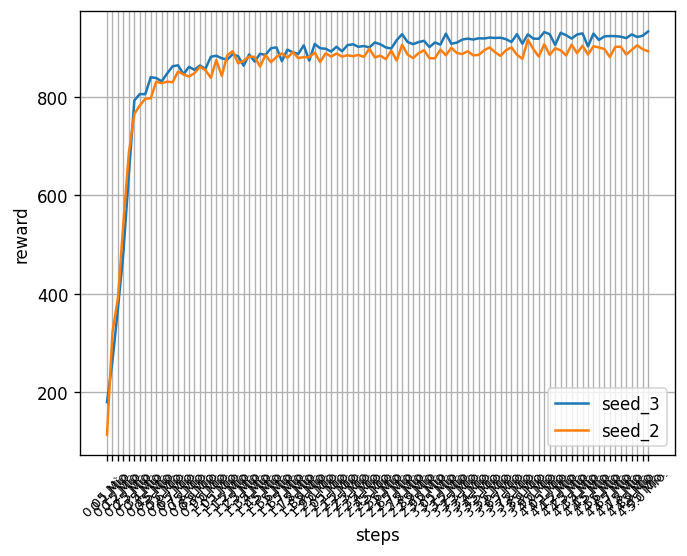

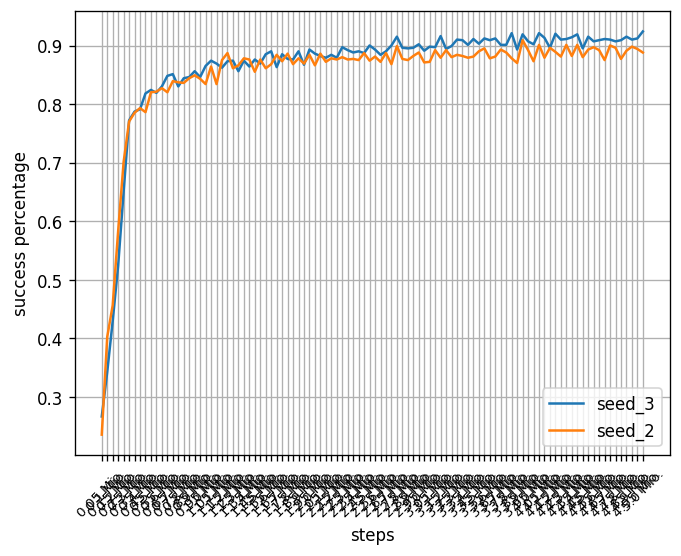

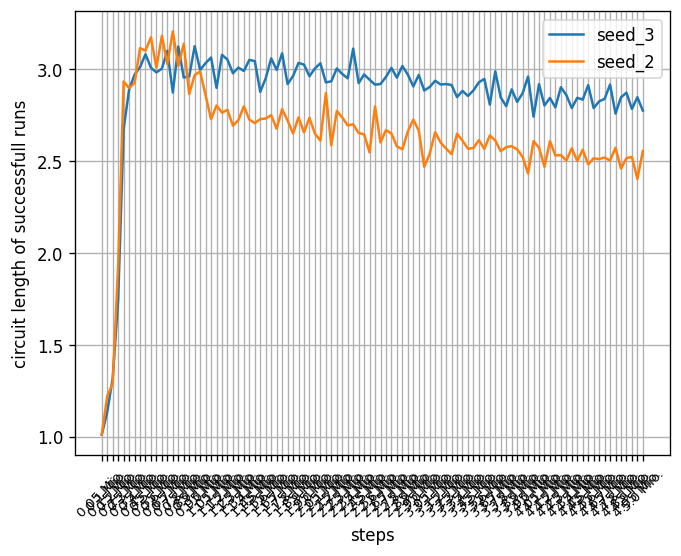


2q_15g_base:
{'common_params': {'max_steps': 15, 'qubit_num': 2, 'seed': 1, 'tag': 'base'},
 'start_time': '2025-09-18 12:38:10.006068',
 'state_generator_params': {'gate_count': 15,
                            'max_generation_tries': 1000000,
                            'targeted_pool_size': 10000,
                            'test_pool_size': 3000,
                            'train_pool_size': 7000,
                            'train_test_split': 0.3},
 'test_env_params': {'eval_freq': 50000, 'n_eval_episodes': 1000},
 'train_params': {'log_interval': 1000, 'total_timesteps': 5000000}}

Aggregated results:


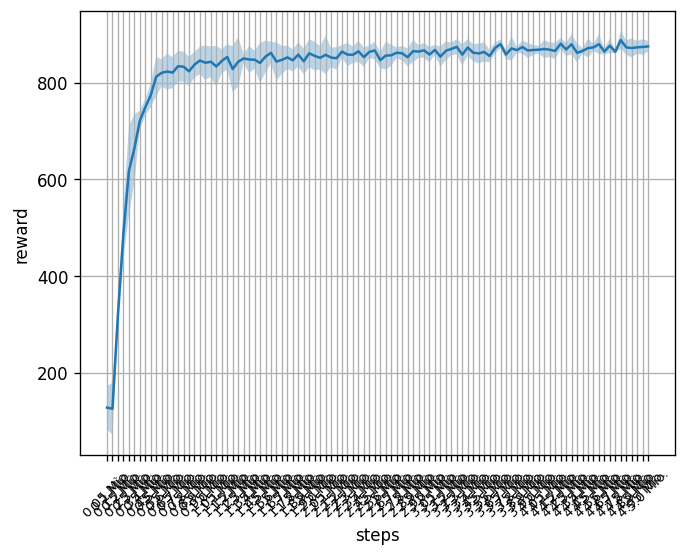

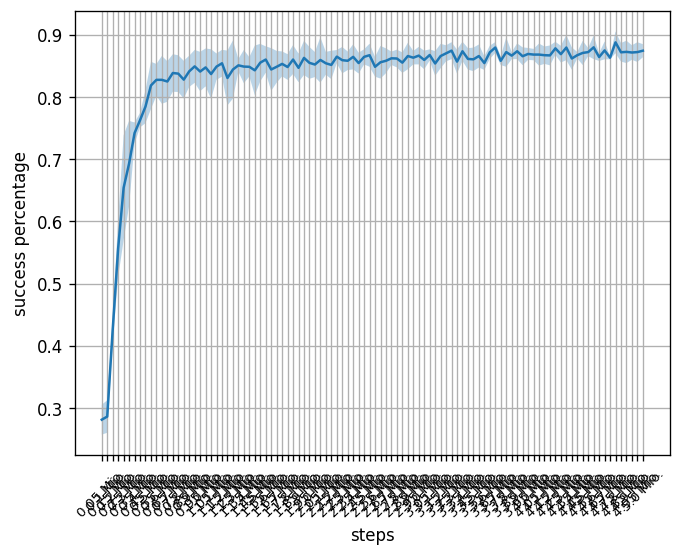

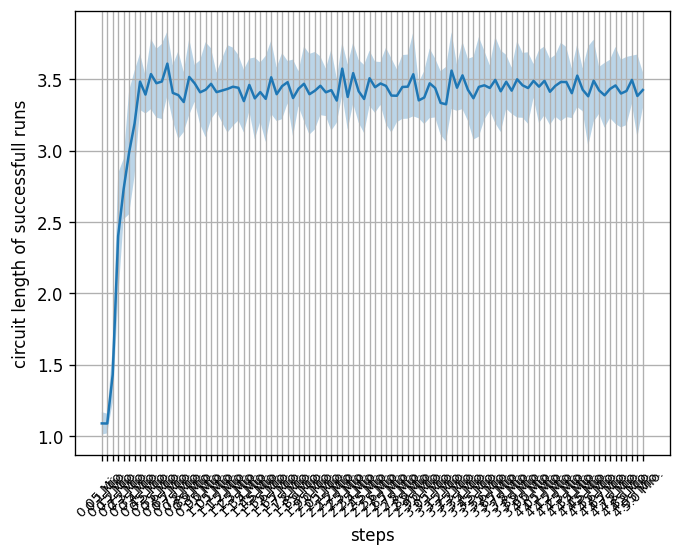


Per seed results:


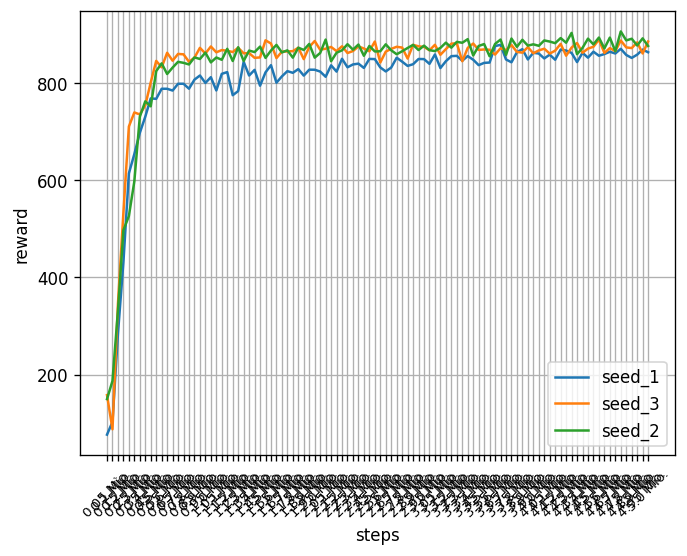

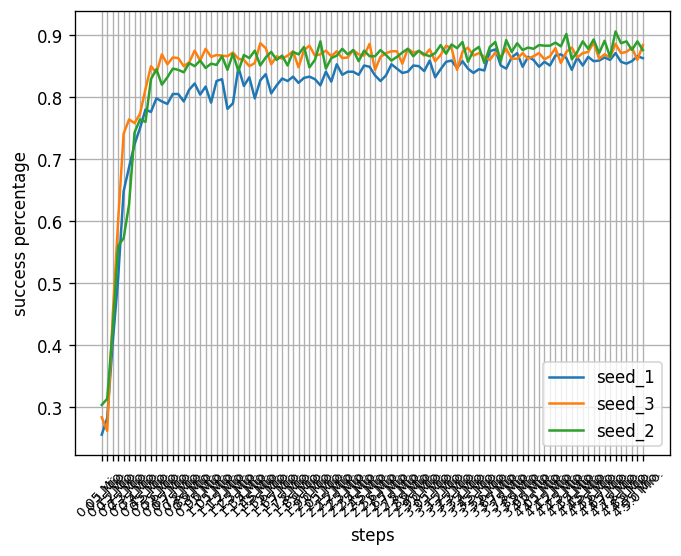

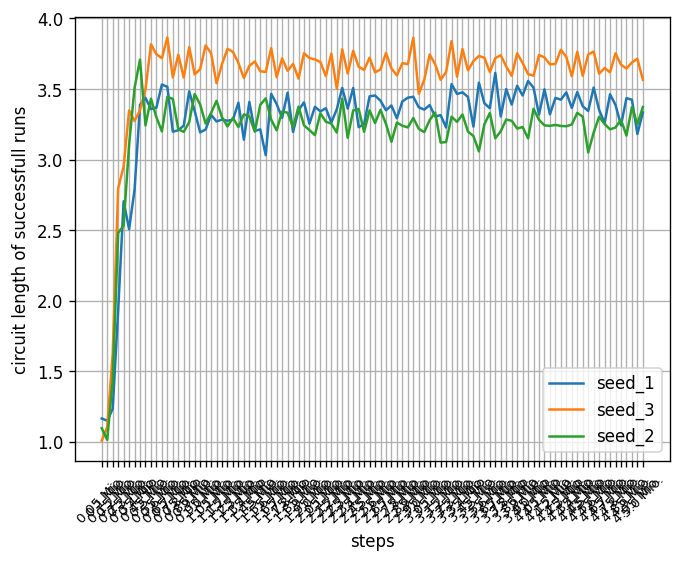


2q_20g_base:
{'common_params': {'max_steps': 20, 'qubit_num': 2, 'seed': 1, 'tag': 'base'},
 'start_time': '2025-09-18 18:58:46.187957',
 'state_generator_params': {'gate_count': 20,
                            'max_generation_tries': 1000000,
                            'targeted_pool_size': 10000,
                            'test_pool_size': 3000,
                            'train_pool_size': 7000,
                            'train_test_split': 0.3},
 'test_env_params': {'eval_freq': 50000, 'n_eval_episodes': 1000},
 'train_params': {'log_interval': 1000, 'total_timesteps': 5000000}}

Aggregated results:


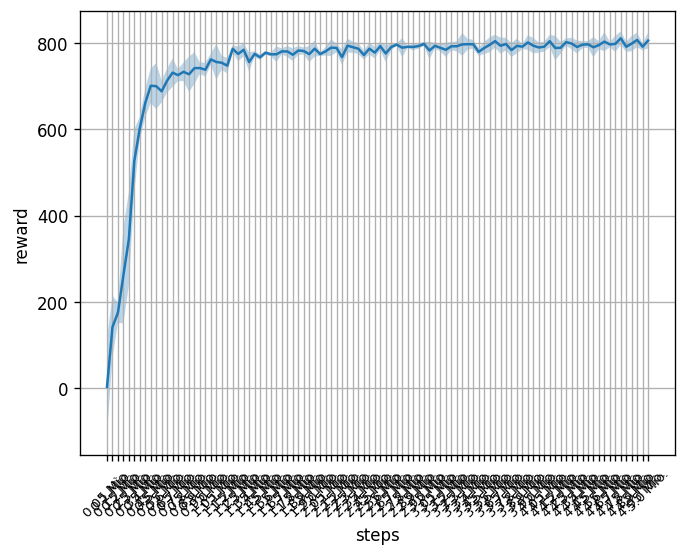

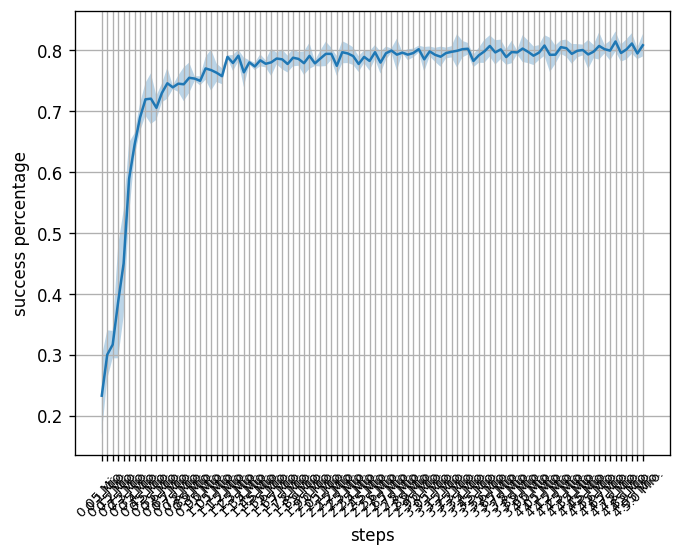

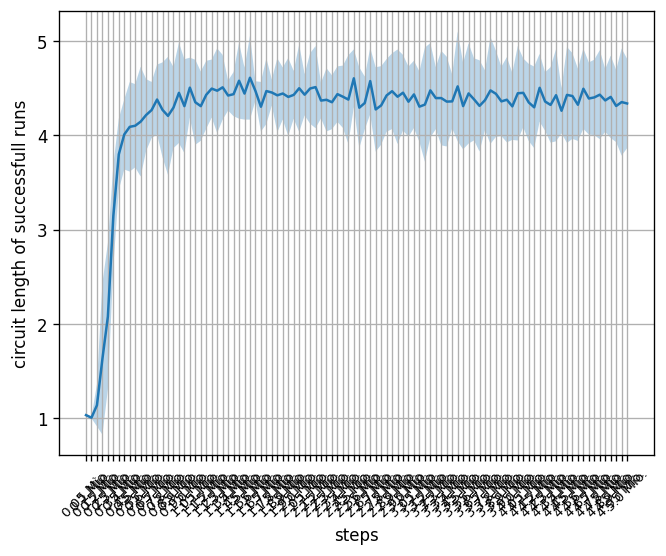


Per seed results:


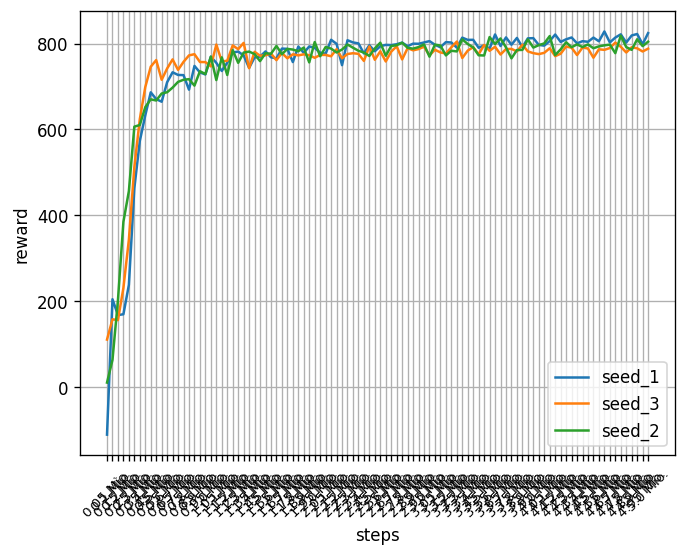

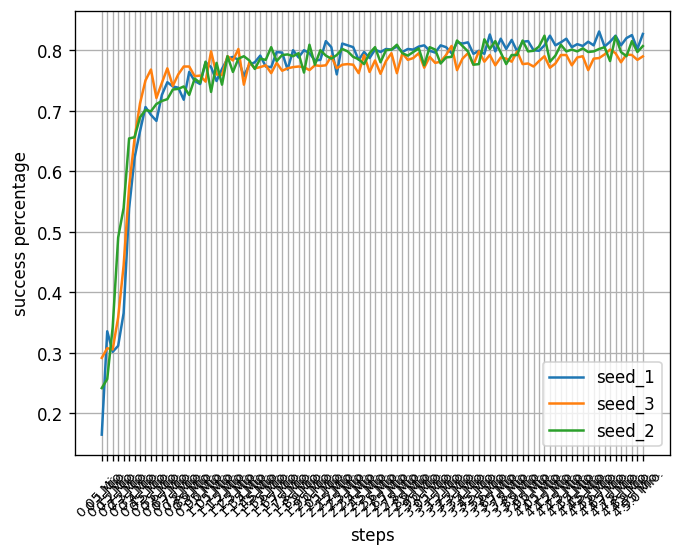

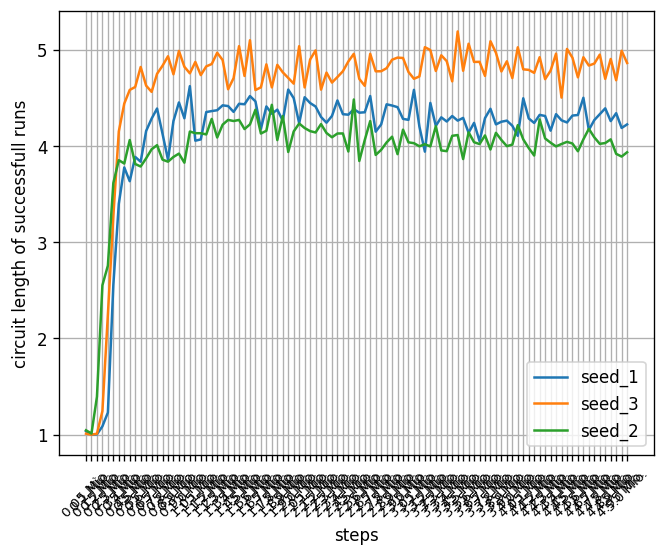


2q_25g_base:
{'common_params': {'max_steps': 25, 'qubit_num': 2, 'seed': 1, 'tag': 'base'},
 'start_time': '2025-09-19 01:33:34.342670',
 'state_generator_params': {'gate_count': 25,
                            'max_generation_tries': 1000000,
                            'targeted_pool_size': 10000,
                            'test_pool_size': 3000,
                            'train_pool_size': 7000,
                            'train_test_split': 0.3},
 'test_env_params': {'eval_freq': 50000, 'n_eval_episodes': 1000},
 'train_params': {'log_interval': 1000, 'total_timesteps': 5000000}}

Aggregated results:


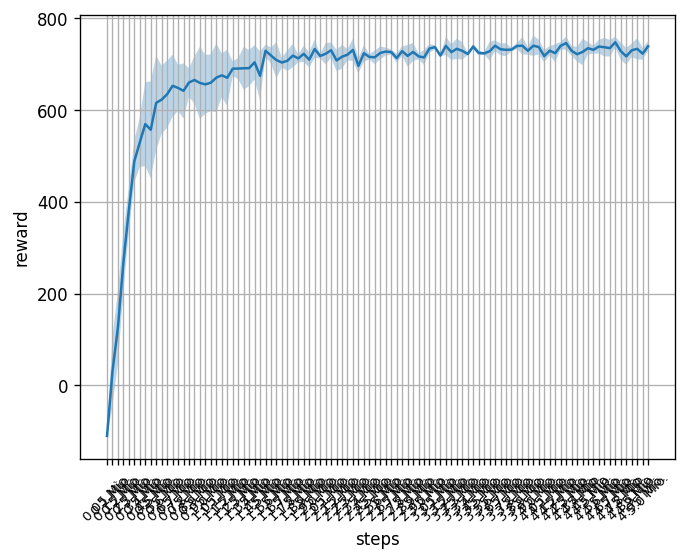

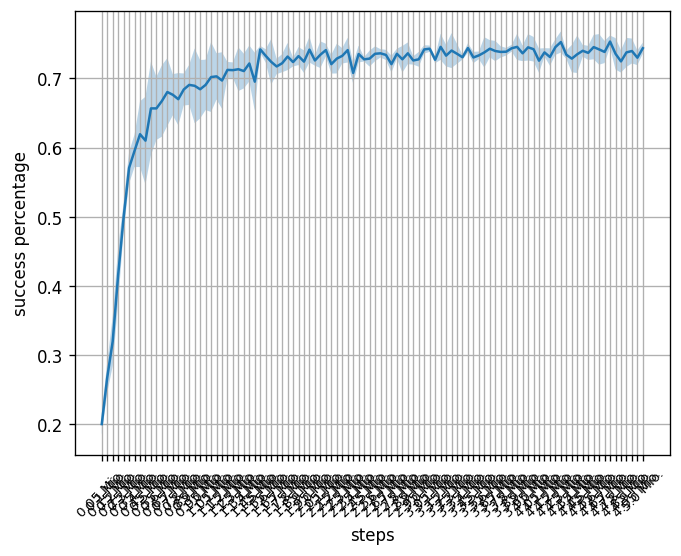

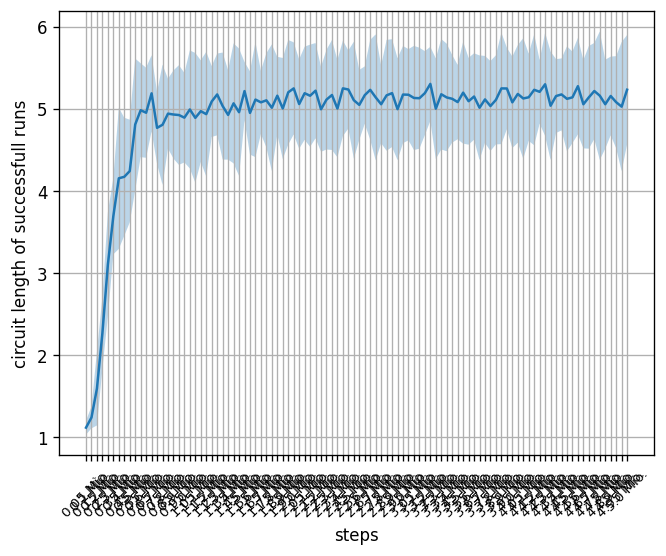


Per seed results:


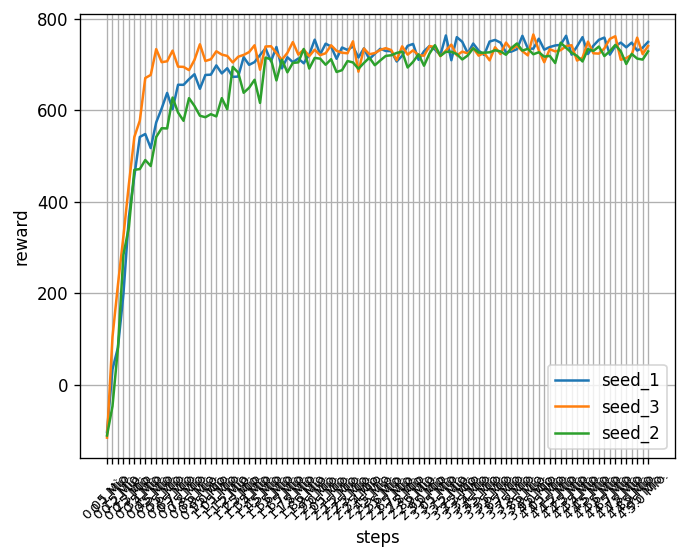

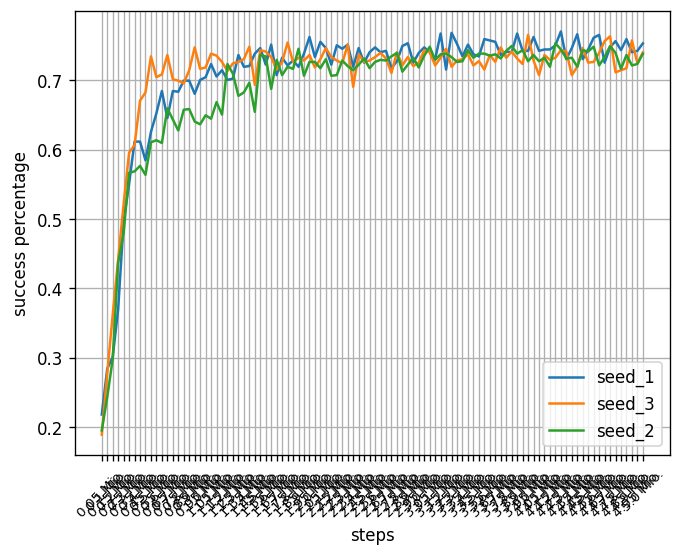

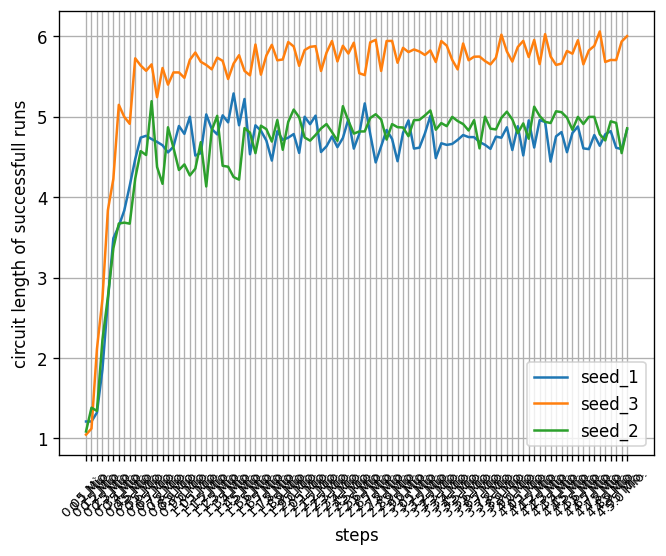


3q_10g_base:
{'common_params': {'max_steps': 10, 'qubit_num': 3, 'seed': 1, 'tag': 'base'},
 'start_time': '2025-09-17 20:36:39.135577',
 'state_generator_params': {'gate_count': 10,
                            'max_generation_tries': 1000000,
                            'targeted_pool_size': 10000,
                            'test_pool_size': 3000,
                            'train_pool_size': 7000,
                            'train_test_split': 0.3},
 'test_env_params': {'eval_freq': 50000, 'n_eval_episodes': 1000},
 'train_params': {'log_interval': 1000, 'total_timesteps': 5000000}}

Aggregated results:


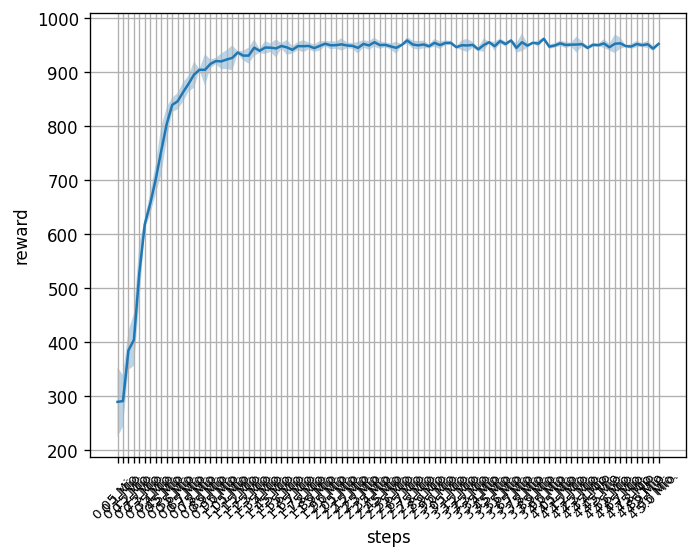

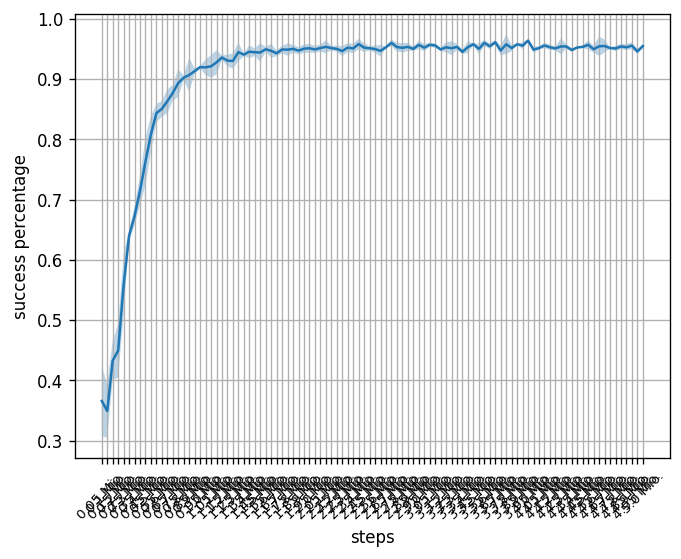

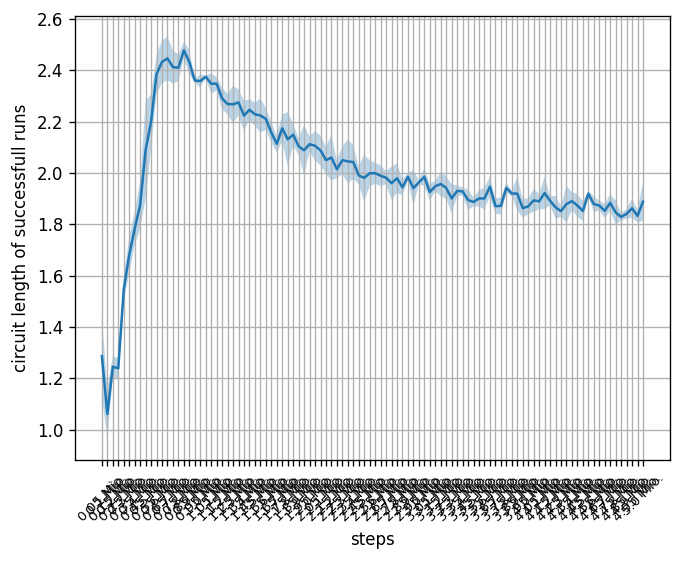


Per seed results:


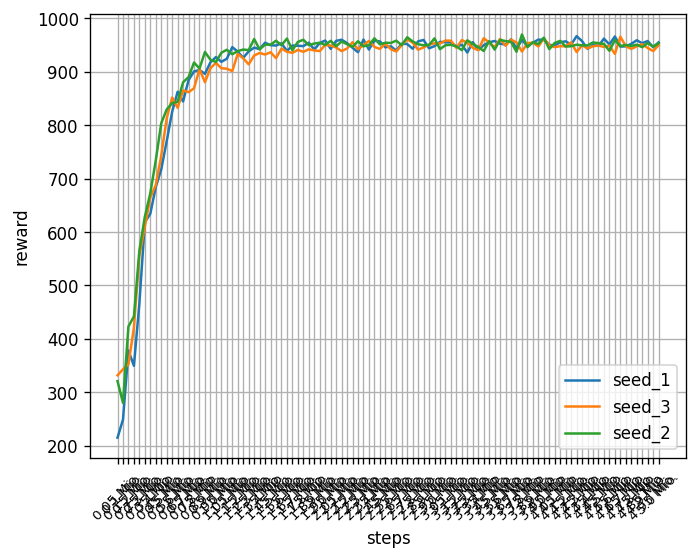

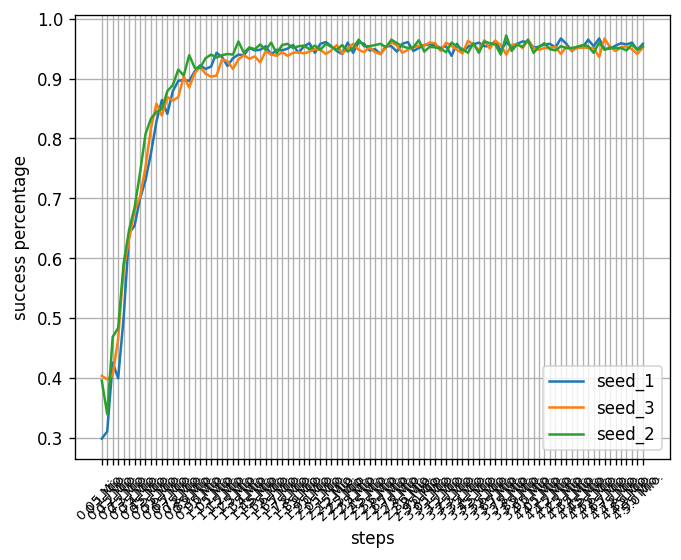

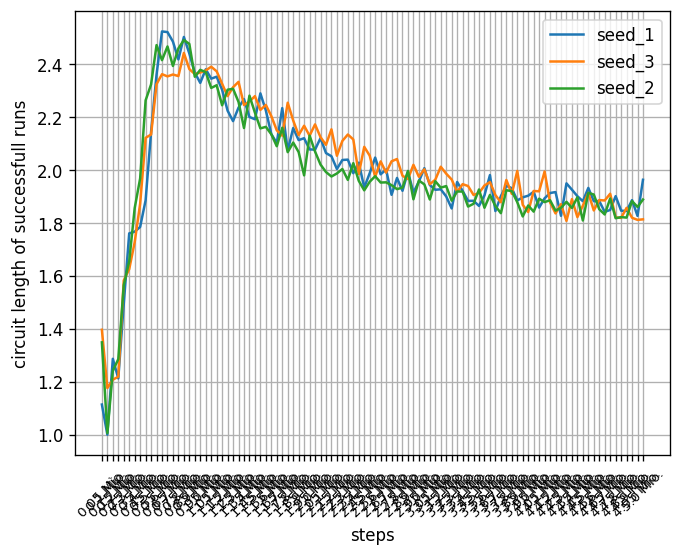


3q_15g_base:
{'common_params': {'max_steps': 15, 'qubit_num': 3, 'seed': 1, 'tag': 'base'},
 'start_time': '2025-09-19 08:15:08.781541',
 'state_generator_params': {'gate_count': 15,
                            'max_generation_tries': 1000000,
                            'targeted_pool_size': 10000,
                            'test_pool_size': 3000,
                            'train_pool_size': 7000,
                            'train_test_split': 0.3},
 'test_env_params': {'eval_freq': 50000, 'n_eval_episodes': 1000},
 'train_params': {'log_interval': 1000, 'total_timesteps': 5000000}}

Aggregated results:


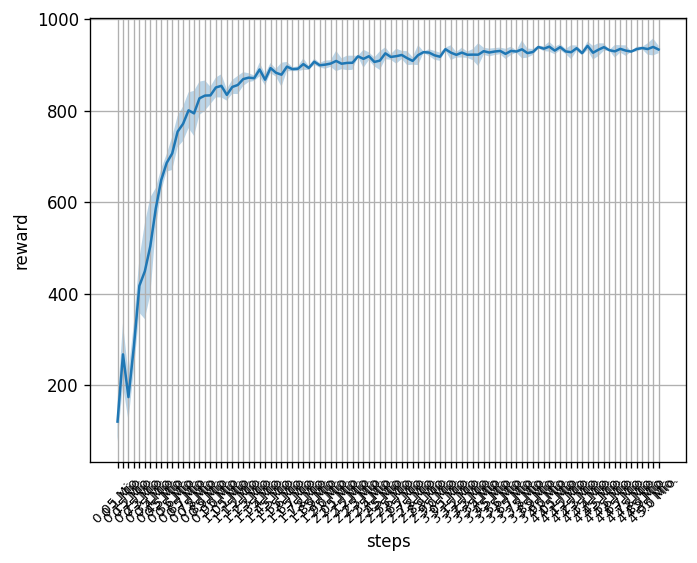

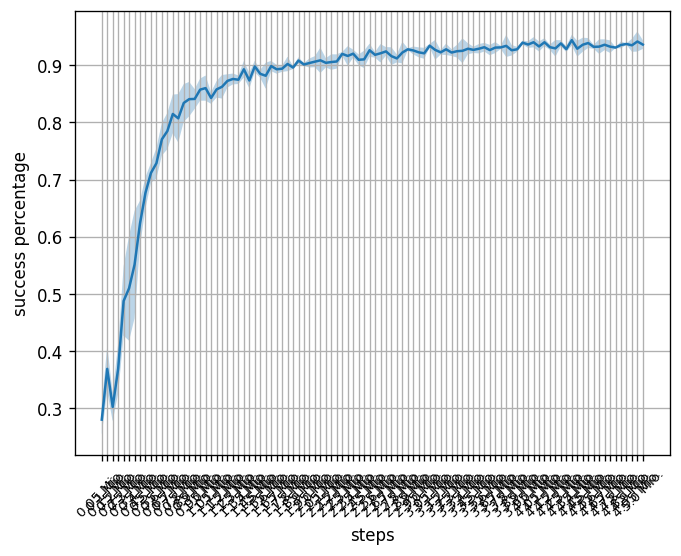

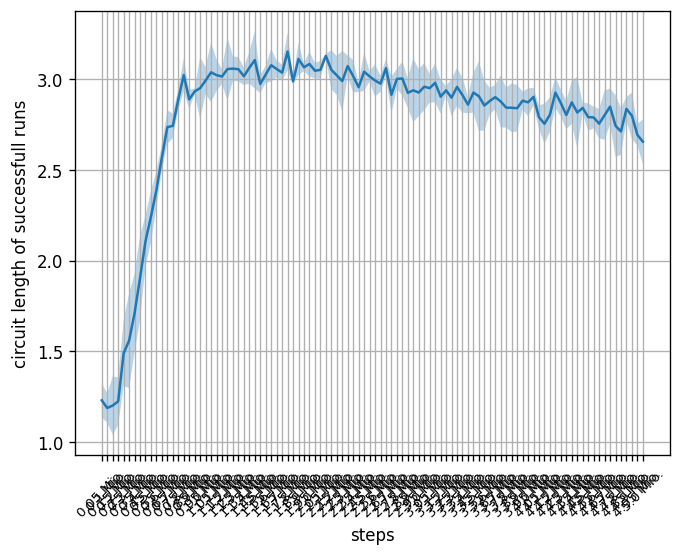


Per seed results:


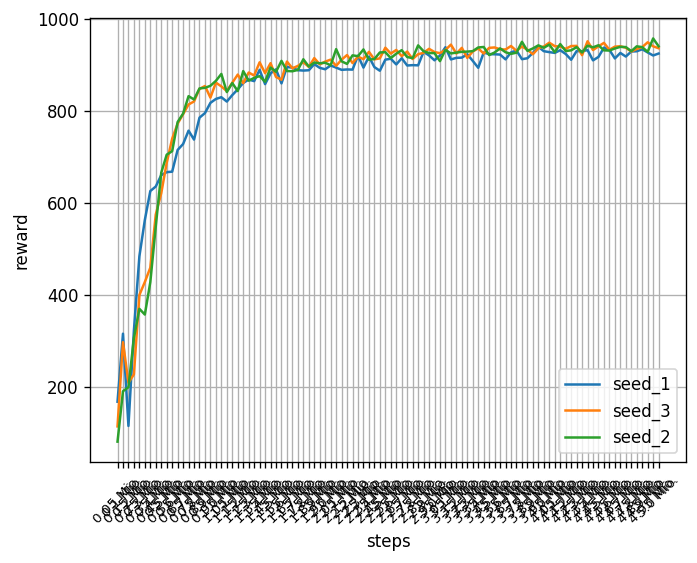

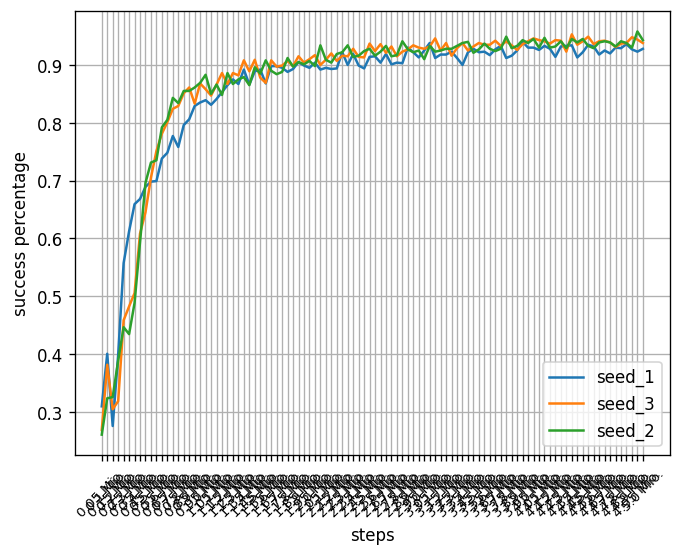

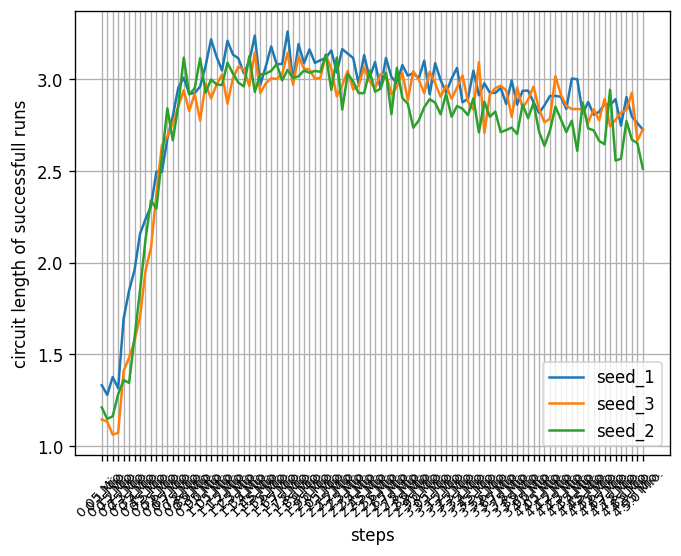


3q_20g_base:
{'common_params': {'max_steps': 20, 'qubit_num': 3, 'seed': 1, 'tag': 'base'},
 'start_time': '2025-09-19 15:57:55.651624',
 'state_generator_params': {'gate_count': 20,
                            'max_generation_tries': 1000000,
                            'targeted_pool_size': 10000,
                            'test_pool_size': 3000,
                            'train_pool_size': 7000,
                            'train_test_split': 0.3},
 'test_env_params': {'eval_freq': 50000, 'n_eval_episodes': 1000},
 'train_params': {'log_interval': 1000, 'total_timesteps': 5000000}}

Aggregated results:


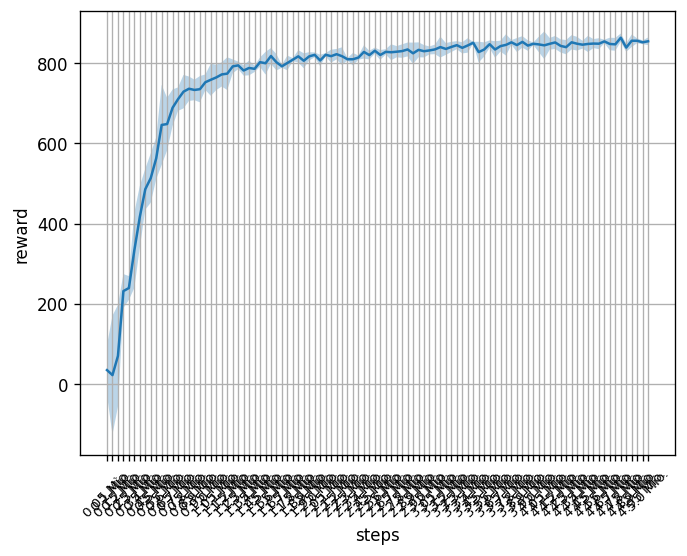

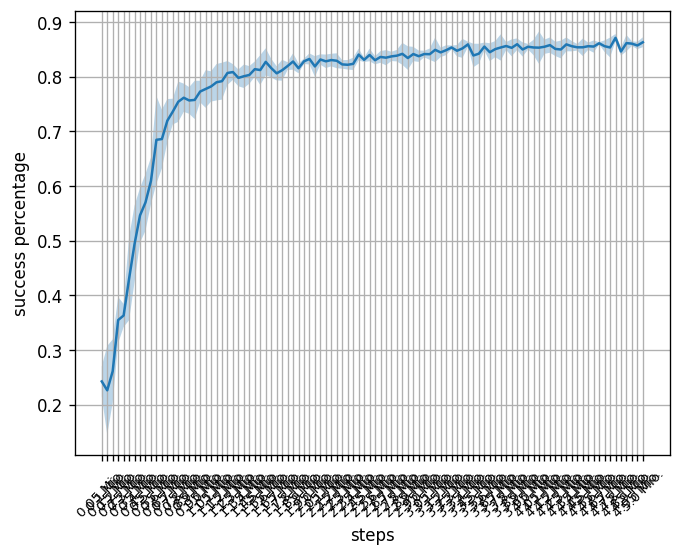

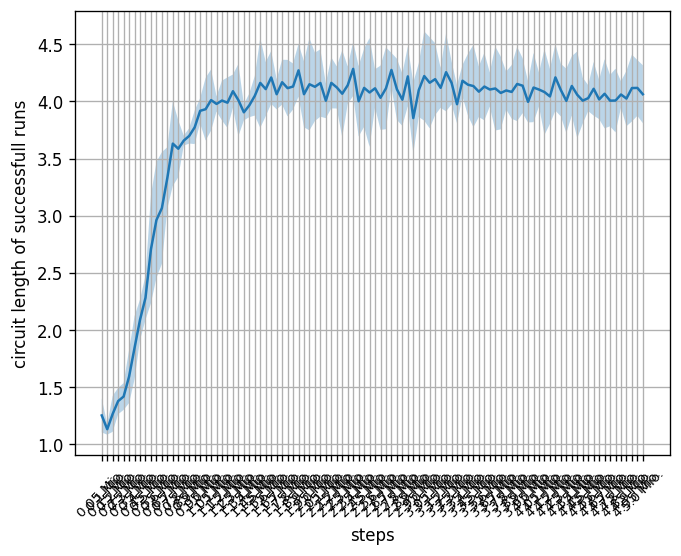


Per seed results:


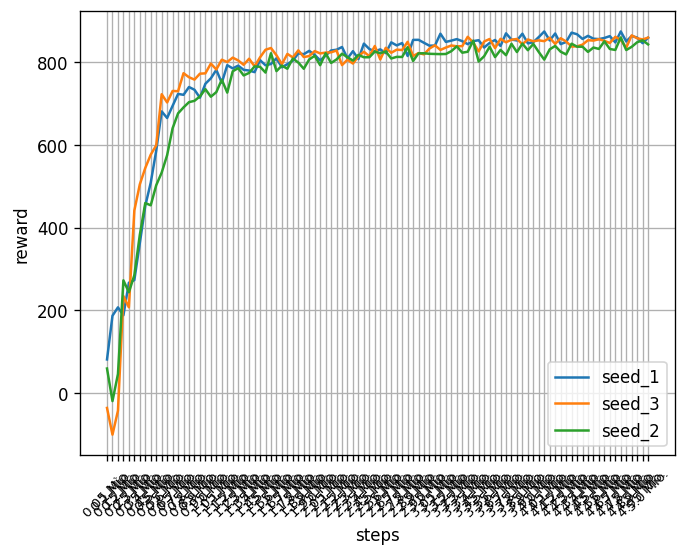

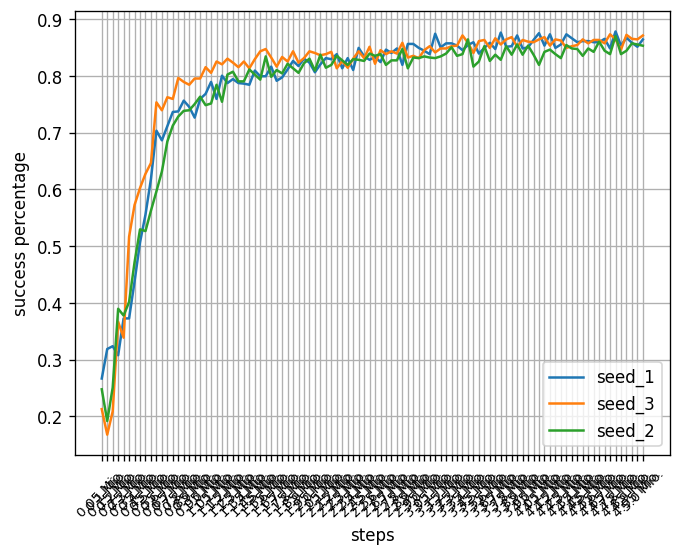

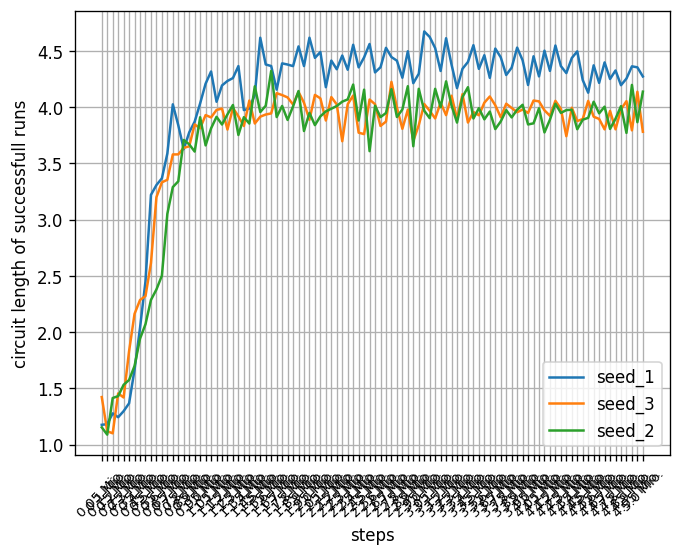


3q_25g_base:
{'common_params': {'max_steps': 25, 'qubit_num': 3, 'seed': 1, 'tag': 'base'},
 'start_time': '2025-09-20 00:00:37.417105',
 'state_generator_params': {'gate_count': 25,
                            'max_generation_tries': 1000000,
                            'targeted_pool_size': 10000,
                            'test_pool_size': 3000,
                            'train_pool_size': 7000,
                            'train_test_split': 0.3},
 'test_env_params': {'eval_freq': 50000, 'n_eval_episodes': 1000},
 'train_params': {'log_interval': 1000, 'total_timesteps': 5000000}}

Aggregated results:


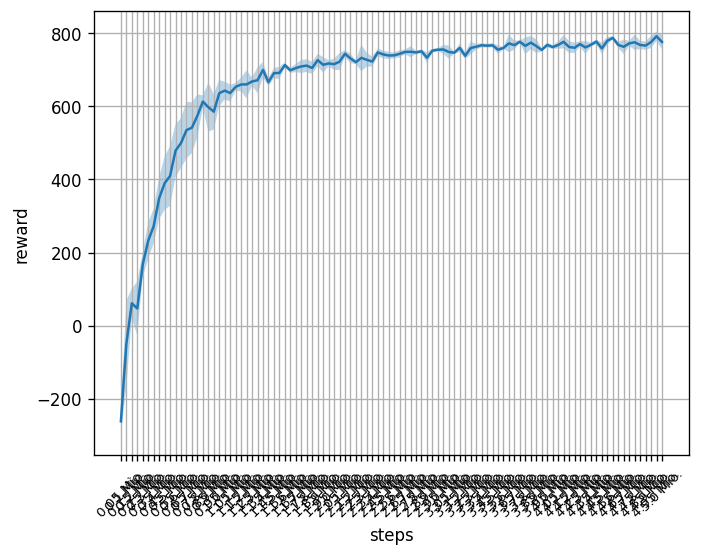

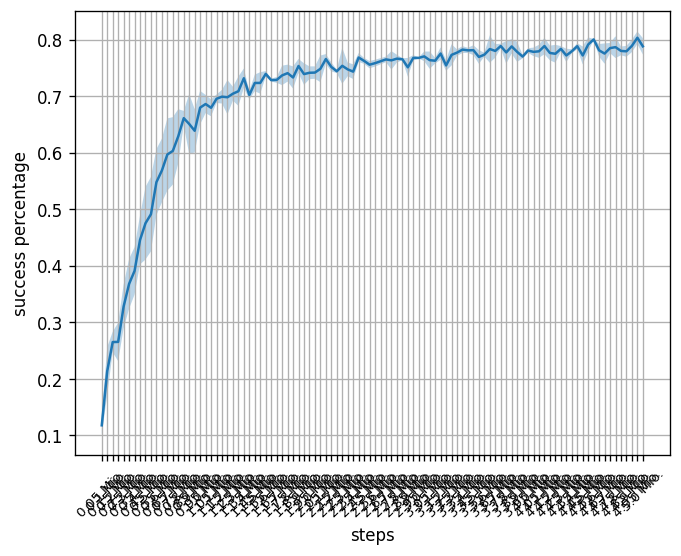

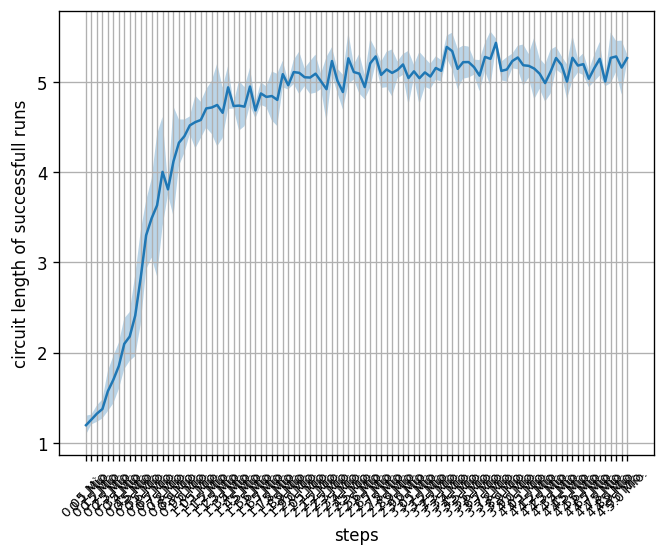


Per seed results:


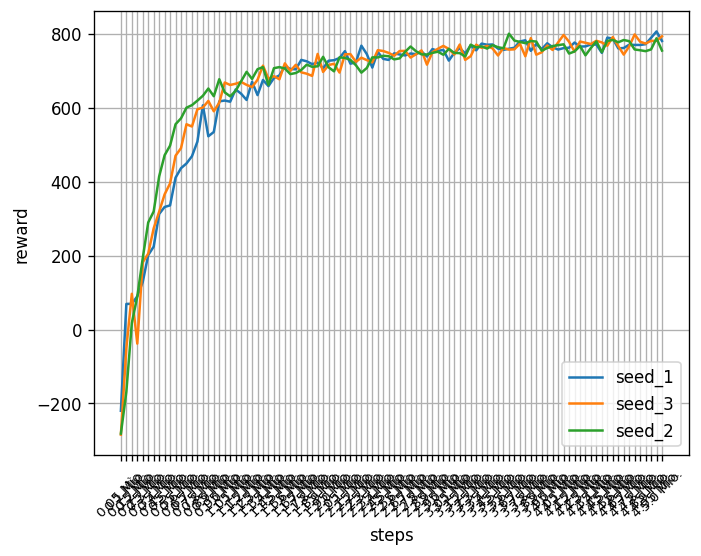

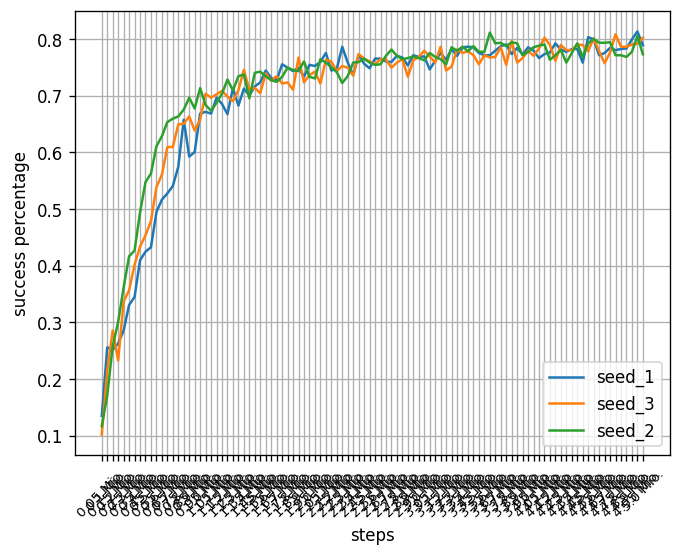

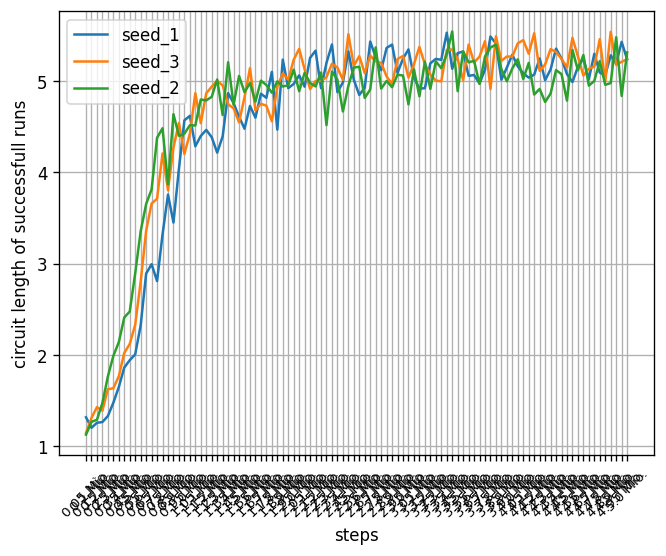


4q_10g_base:
{'common_params': {'max_steps': 10, 'qubit_num': 4, 'seed': 1, 'tag': 'base'},
 'start_time': '2025-09-20 08:21:14.939475',
 'state_generator_params': {'gate_count': 10,
                            'max_generation_tries': 10000000,
                            'targeted_pool_size': 10000,
                            'test_pool_size': 3000,
                            'train_pool_size': 7000,
                            'train_test_split': 0.3},
 'test_env_params': {'eval_freq': 50000, 'n_eval_episodes': 1000},
 'train_params': {'log_interval': 1000, 'total_timesteps': 5000000}}

Aggregated results:


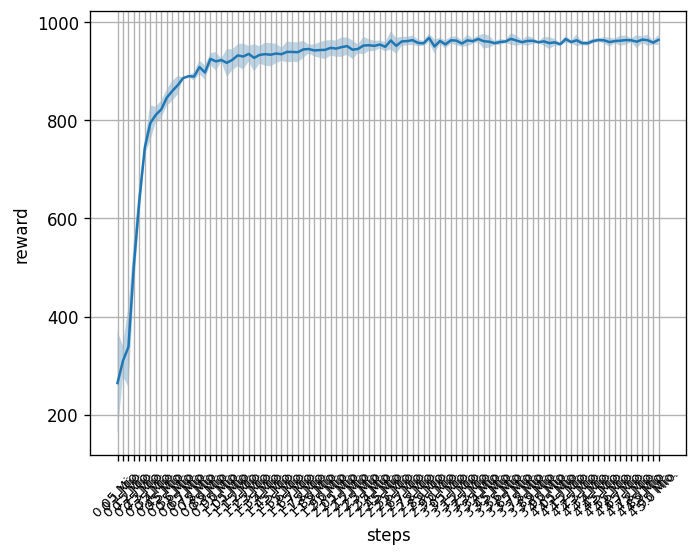

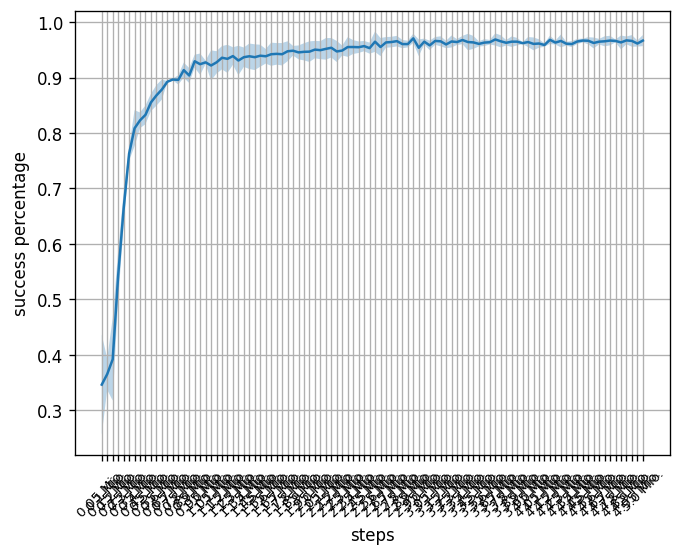

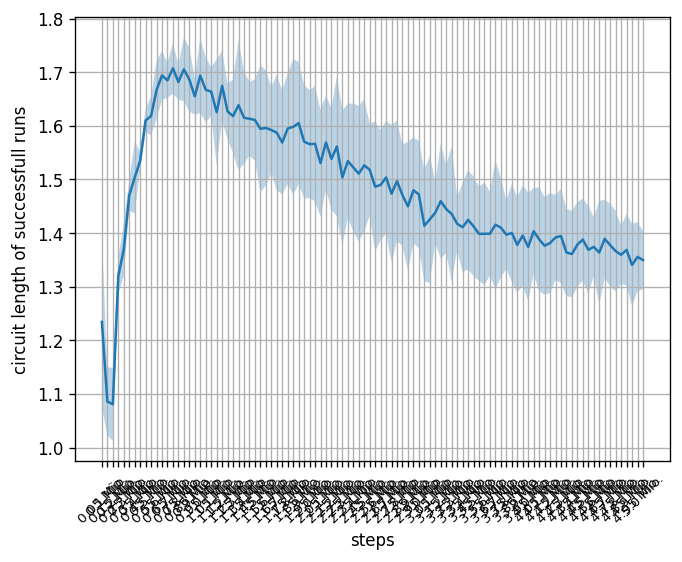


Per seed results:


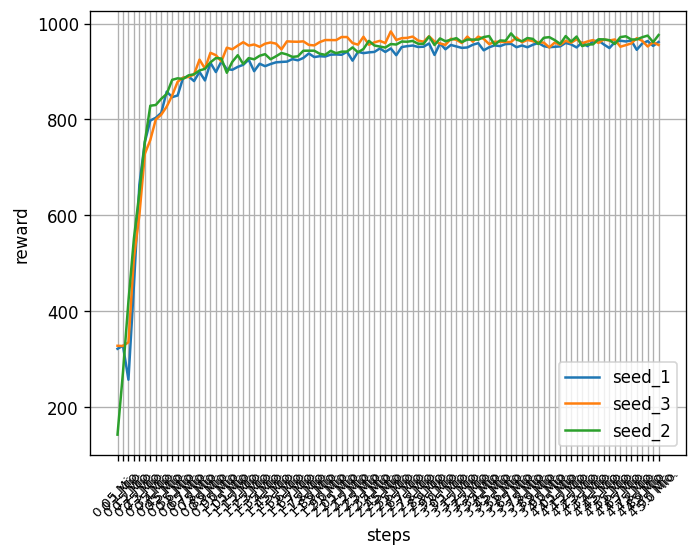

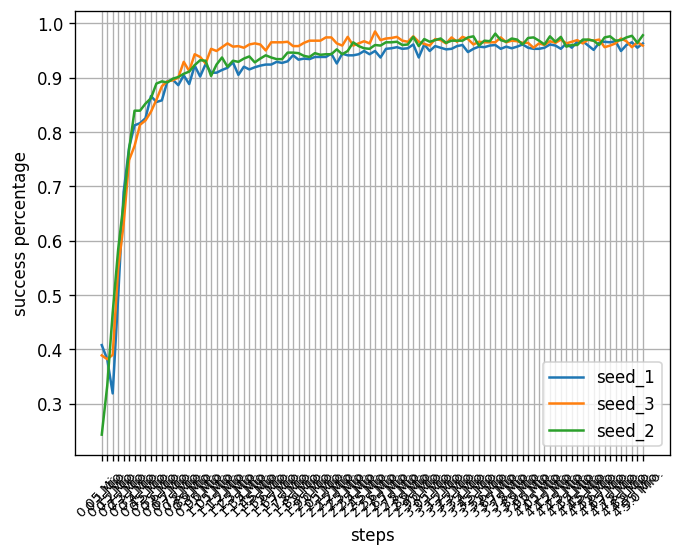

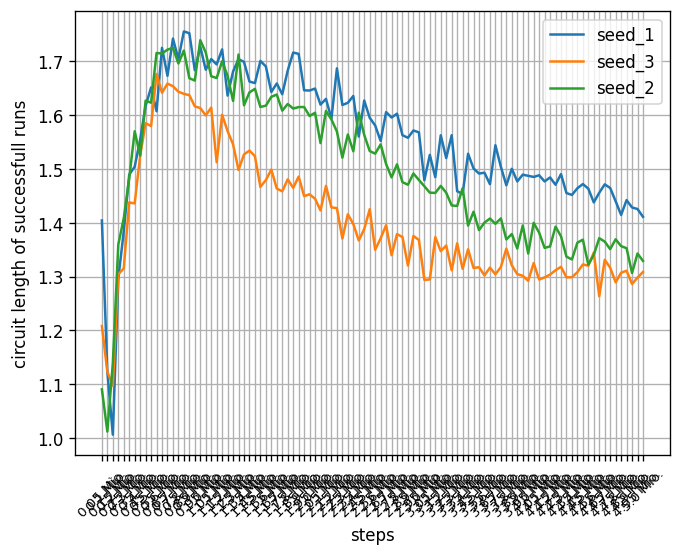


4q_15g_base:
{'common_params': {'max_steps': 15, 'qubit_num': 4, 'seed': 1, 'tag': 'base'},
 'start_time': '2025-09-20 18:20:16.707847',
 'state_generator_params': {'gate_count': 15,
                            'max_generation_tries': 10000000,
                            'targeted_pool_size': 10000,
                            'test_pool_size': 3000,
                            'train_pool_size': 7000,
                            'train_test_split': 0.3},
 'test_env_params': {'eval_freq': 50000, 'n_eval_episodes': 1000},
 'train_params': {'log_interval': 1000, 'total_timesteps': 5000000}}

Aggregated results:


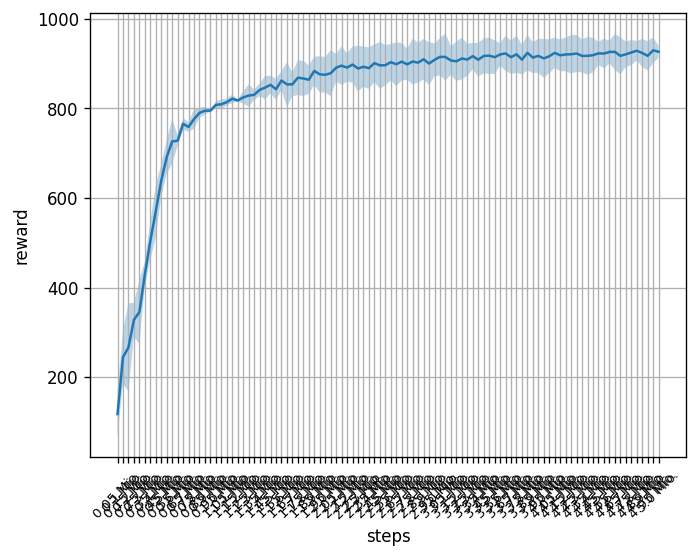

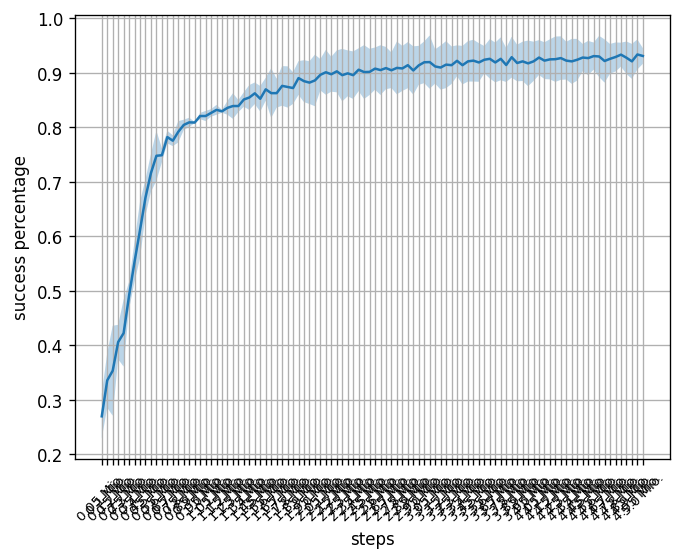

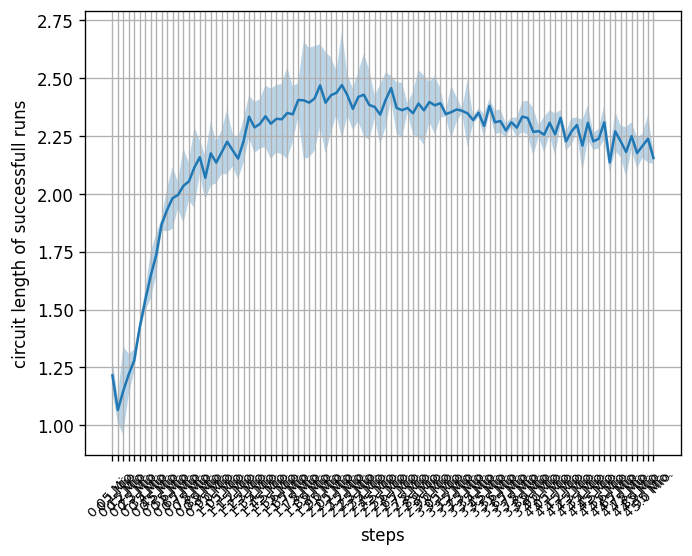


Per seed results:


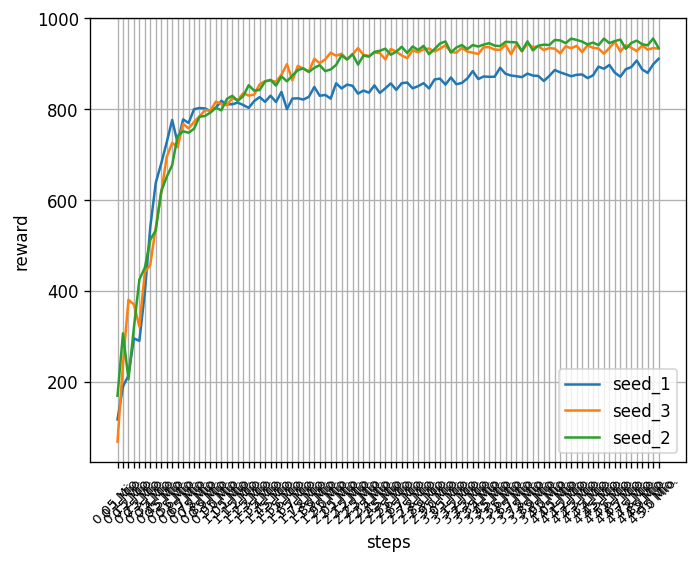

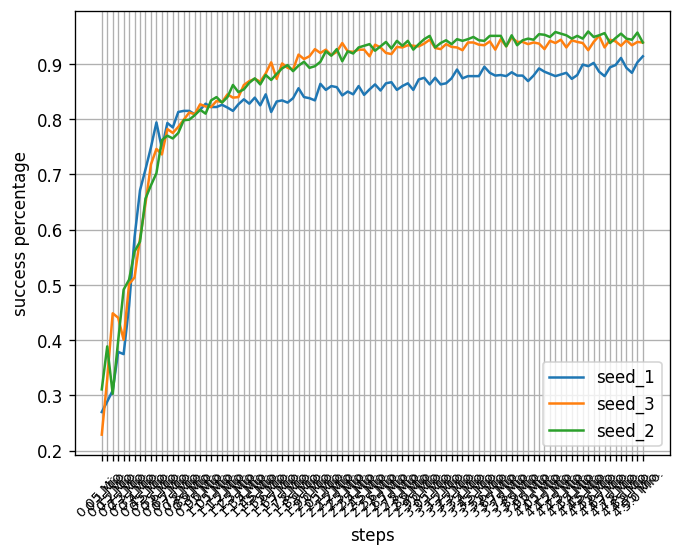

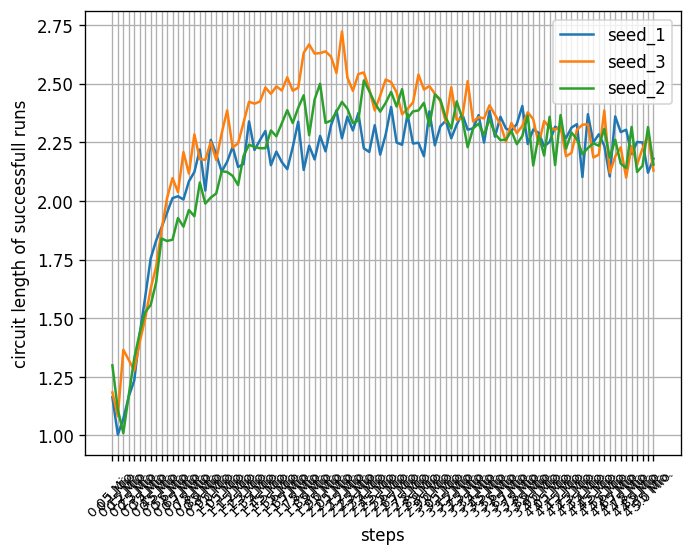


4q_20g_base:
{'common_params': {'max_steps': 20, 'qubit_num': 4, 'seed': 1, 'tag': 'base'},
 'start_time': '2025-09-21 04:39:37.540502',
 'state_generator_params': {'gate_count': 20,
                            'max_generation_tries': 10000000,
                            'targeted_pool_size': 10000,
                            'test_pool_size': 3000,
                            'train_pool_size': 7000,
                            'train_test_split': 0.3},
 'test_env_params': {'eval_freq': 50000, 'n_eval_episodes': 1000},
 'train_params': {'log_interval': 1000, 'total_timesteps': 5000000}}

Aggregated results:


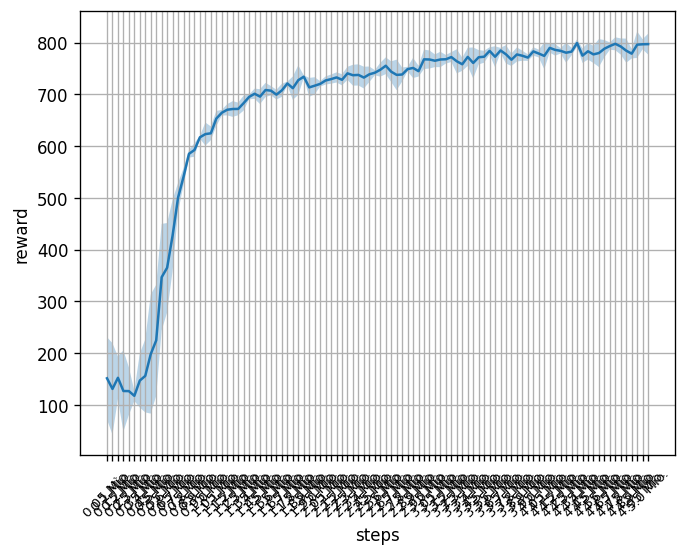

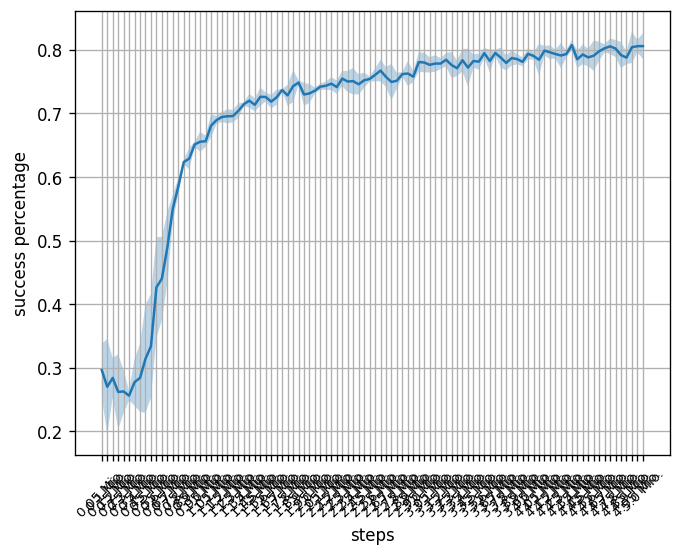

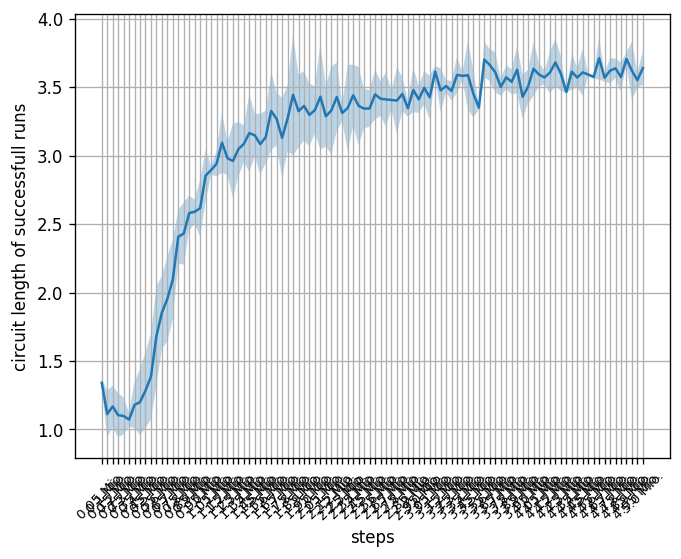


Per seed results:


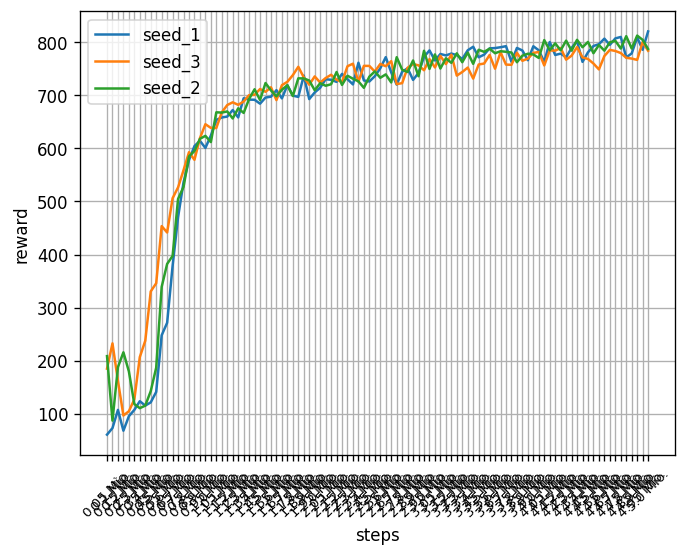

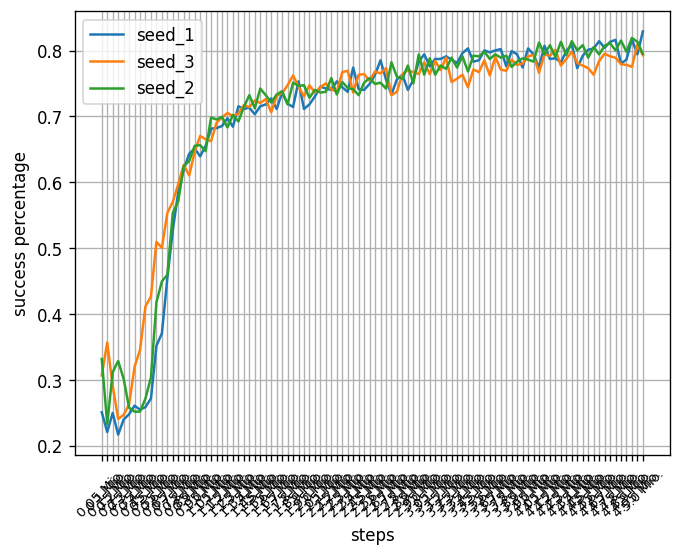

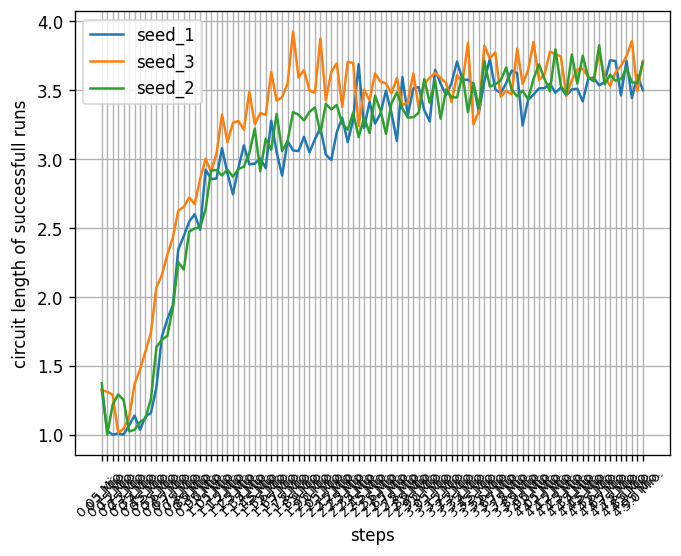


4q_25g_base:
{'common_params': {'max_steps': 25, 'qubit_num': 4, 'seed': 1, 'tag': 'base'},
 'start_time': '2025-09-21 15:47:50.667088',
 'state_generator_params': {'gate_count': 25,
                            'max_generation_tries': 10000000,
                            'targeted_pool_size': 10000,
                            'test_pool_size': 3000,
                            'train_pool_size': 7000,
                            'train_test_split': 0.3},
 'test_env_params': {'eval_freq': 50000, 'n_eval_episodes': 1000},
 'train_params': {'log_interval': 1000, 'total_timesteps': 5000000}}

Aggregated results:


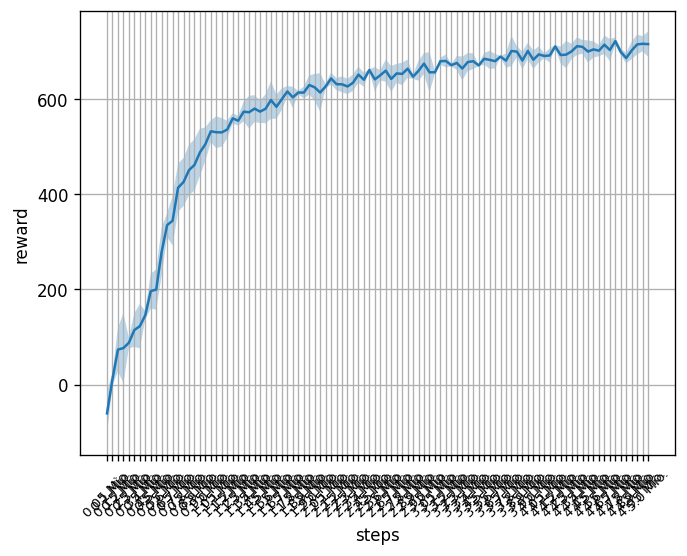

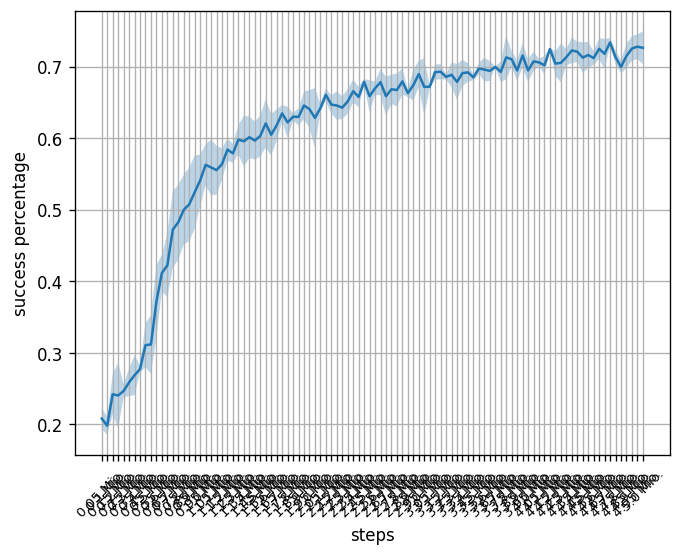

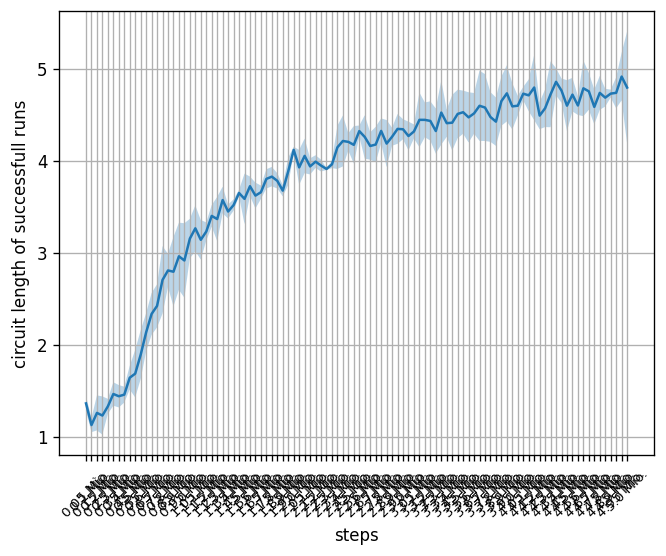


Per seed results:


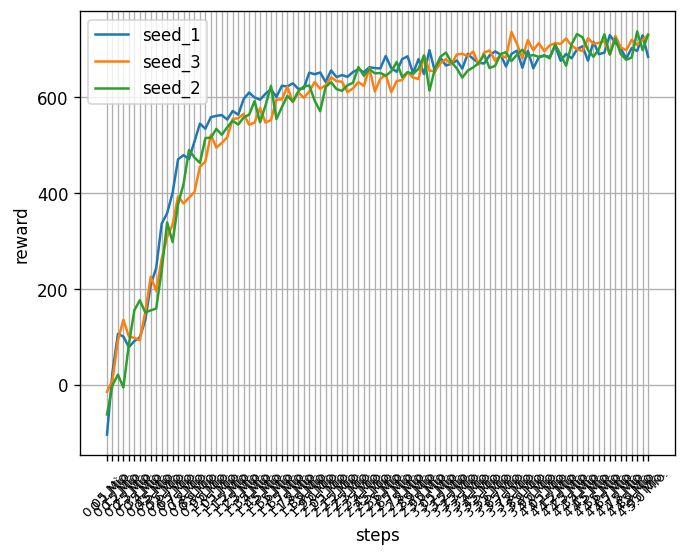

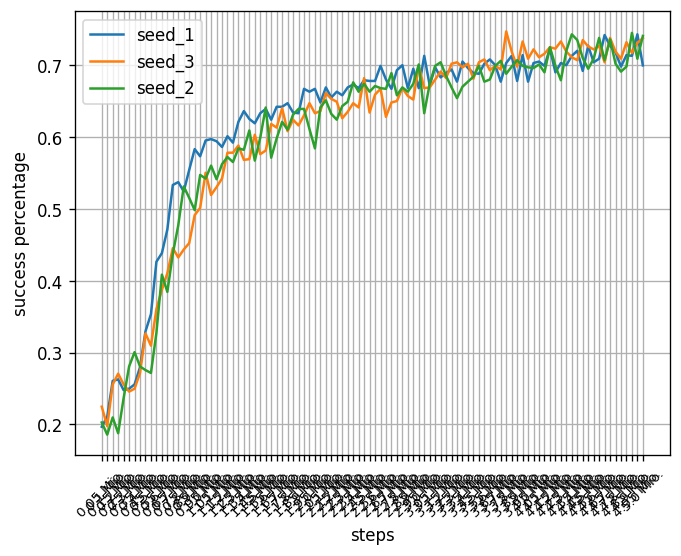

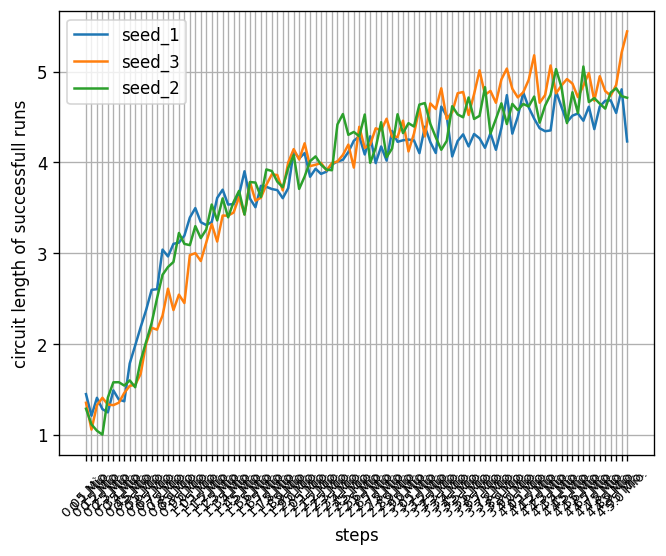

In [12]:
experiment_dir_paths = [res.path for res in os.scandir(LOG_DIR) if res.is_dir()]
experiment_dir_paths.sort()

for experiment_dir_path in experiment_dir_paths:
    experiment_config_name = experiment_dir_path.split("/")[-1]

    printb(f"\n{experiment_config_name}:")

    experiment_seed_dir_paths = [res.path for res in os.scandir(experiment_dir_path) if res.is_dir()]

    experiment_seed_configs = [
        load_json(f"{dir_path}/config.json") for dir_path in experiment_seed_dir_paths
    ]

    pprint(experiment_seed_configs[0])

    experiment_seed_dfs = []
    for config, path in zip(experiment_seed_configs, experiment_seed_dir_paths):

        # TODO: config param naming glattziehen
        df = load_monitor_data(f"{path}/test.monitor.csv",  
                    n_eval_episodes=config["test_env_params"]["n_eval_episodes"], 
                    episode_cutoff=config["common_params"]["max_steps"], 
                    eval_frequency=config["test_env_params"]["eval_freq"]
                )
        experiment_seed_dfs.append(df)

    experiment_df = merge_seed_dfs(experiment_seed_dfs)

    seed_labels = [
        f"seed_{config['common_params']['seed']}" for config in experiment_seed_configs
    ]

    print("\nAggregated results:")
    plot_rewards([experiment_df], labels=[None])
    plot_succ_pct_per_experiment([experiment_df], labels=[None], plot_stdev=True)
    plot_circuit_lengths([experiment_df], labels=[None])

    print("\nPer seed results:")
    plot_rewards(experiment_seed_dfs, seed_labels, plot_stdev=False)
    plot_succ_pct_per_seed(experiment_seed_dfs, seed_labels)
    plot_circuit_lengths(experiment_seed_dfs, seed_labels, plot_stdev=False)

    
